<a href="https://colab.research.google.com/github/Prajkta11222/Market-Basket-Analysis-ML/blob/main/MARKET_BASKET_ML(CS23024%2CCS23031).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Market-Basket-Analysis-ML

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [62]:
import pandas as pd
url = "https://raw.githubusercontent.com/Prajkta11222/Market-Basket-Analysis-ML/main/Groceries_dataset.csv"
data = pd.read_csv(url)
data.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [63]:
data.shape

(38765, 3)

In [64]:
transactions = data.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

In [65]:
transactions[:5]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables']]

In [66]:
!pip install mlxtend

In [67]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
te = TransactionEncoder()

te_data = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_data, columns=te.columns_)

df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [69]:
item_counts = df.sum().sort_values(ascending=False)

item_counts.head(10)

,0
whole milk,2363
other vegetables,1827
rolls/buns,1646
soda,1453
yogurt,1285
root vegetables,1041
tropical fruit,1014
bottled water,908
sausage,903
citrus fruit,795


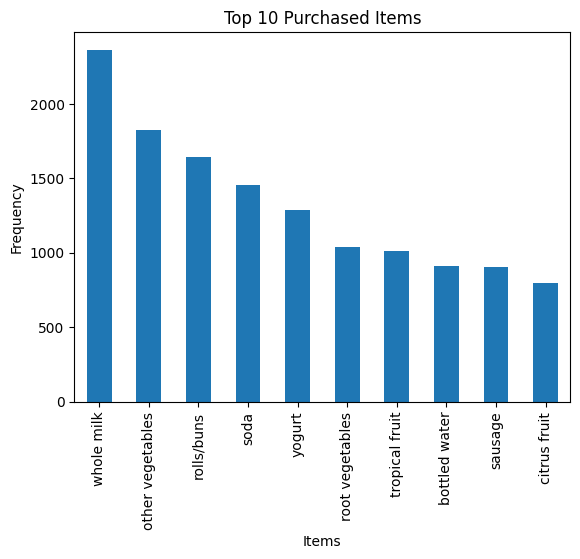

In [70]:
item_counts.head(10).plot(kind='bar')

plt.title("Top 10 Purchased Items")

plt.xlabel("Items")

plt.ylabel("Frequency")

plt.show()

Model 1: Apriori Algorithm

In [71]:
# Import Apriori and association rule functions
from mlxtend.frequent_patterns import apriori, association_rules

In [72]:
# Find frequent itemsets (items appearing in at least 1% transactions)
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

In [73]:
# Show first few frequent itemsets
frequent_itemsets.head()

,support,itemsets
0,0.021386,(UHT-milk)
1,0.033950,(beef)
2,0.021787,(berries)
3,0.016574,(beverages)
4,0.045312,(bottled beer)


In [74]:
# Generate association rules using confidence metric
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

In [75]:
# Display top rules
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
1,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
2,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694
3,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317


FP GROWTH


In [82]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import fpgrowth, association_rules

In [83]:
# Step 1: Apply FP-Growth algorithm
fp_items = fpgrowth(df, min_support=0.01, use_colnames=True)

In [84]:
# Display frequent itemsets
fp_items.head()

,support,itemsets
0,0.157923,(whole milk)
1,0.085879,(yogurt)
2,0.060349,(sausage)
3,0.051728,(pastry)
4,0.018780,(salty snack)


In [85]:
# Step 2: Show frequent itemsets
print("Frequent Itemsets:")
display(fp_items.head())

Frequent Itemsets:


,support,itemsets
0,0.157923,(whole milk)
1,0.085879,(yogurt)
2,0.060349,(sausage)
3,0.051728,(pastry)
4,0.018780,(salty snack)


In [86]:
# Step 3: Generate association rules
# Lowering the min_threshold for confidence to generate more rules
fp_rules = association_rules(fp_items, metric="confidence", min_threshold=0.1)

In [87]:
# Step 4: Show rules
print("\nAssociation Rules:")
print(fp_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


Association Rules:
          antecedents   consequents   support  confidence      lift
0            (yogurt)  (whole milk)  0.011161    0.129961  0.822940
1              (soda)  (whole milk)  0.011629    0.119752  0.758296
2        (rolls/buns)  (whole milk)  0.013968    0.126974  0.804028
3  (other vegetables)  (whole milk)  0.014837    0.121511  0.769430


In [80]:
# Step 5: Sort rules by lift (important)
fp_rules_sorted = fp_rules.sort_values(by="lift", ascending=False)

In [81]:
# Step 6: Show top 10 strong rules
print("\nTop 10 Rules by Lift:")
print(fp_rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Top 10 Rules by Lift:
          antecedents   consequents   support  confidence      lift
0            (yogurt)  (whole milk)  0.011161    0.129961  0.822940
2        (rolls/buns)  (whole milk)  0.013968    0.126974  0.804028
3  (other vegetables)  (whole milk)  0.014837    0.121511  0.769430
1              (soda)  (whole milk)  0.011629    0.119752  0.758296
